In [103]:
# Load Excel File 'Online Sales Retailer'

import pandas as pd

# Seperate Dataframe for each sheet Sales, Invoice & Product
df_sales = pd.read_excel(f"{notebookutils.nbResPath}/builtin/Online Sales Retailer.xlsx" , sheet_name= 'Sales')
df_invoice = pd.read_excel(f"{notebookutils.nbResPath}/builtin/Online Sales Retailer.xlsx" , sheet_name= 'Invoice')
df_product = pd.read_excel(f"{notebookutils.nbResPath}/builtin/Online Sales Retailer.xlsx" , sheet_name= 'Product')

# Display first few rows of each Dataframe
display(df_sales.head(3))
display(df_invoice.head(3))
display(df_product.head(3))

In [104]:
# Create Sales Column (Quantity * Unit Price)
df_sales['Sales'] = df_sales['Quantity'] * df_sales['UnitPrice']

# Display Sales Column 
display(df_sales[['Sales']])

In [105]:
# Check for missing values in the Sales Dataset
# Using isnull() alias:

missing_values = df_sales.isnull()

# Display table: false = non-null cells
display(missing_values)  

# Print column summary: 0 = no missing values as further verification
print(df_sales.isnull().sum())  

InvoiceNo      0
StockCode      0
Quantity       0
UnitPrice      0
InvoiceDate    0
Sales          0
dtype: int64


**Note**: No true (null) cells found in Sales dataset 

**Column Summary**: 0 = no missing values as further verification

In [106]:
# Display only rows with null values
rows_with_nulls = df_sales[missing_values.any(axis=1)]

# Display the rows with null values
display(rows_with_nulls)

**Note**: Result is an empty Dataframe confirming no null records in the Sales dataset

In [107]:
# Replace NaN values in the Sales and UnitPrice columns with 0
# Using fillna

df_sales['Sales'] = df_sales['Sales'].fillna(0)
df_sales['UnitPrice'] = df_sales['UnitPrice'].fillna(0)

display(df_sales[['Sales', 'UnitPrice']].head()) # Display top only

**Note**: No Nan values found in Sales & UnitPrice Columns. No change to data post execution

In [108]:
# Calculate basic descriptive statistics for the Quantity and UnitPrice columns (mean, mediun, mode, standard deviation)

# Quantity
mean_Quantity = df_sales['Quantity'].mean() # Gives the average of the Quantity column
median_Quantity = df_sales['Quantity'].median() # Gives the middle value when sorted
mode_Quantity = df_sales['Quantity'].mode() # Gives the most frequent value 
std_Quantity = df_sales['Quantity'].std() # Measures how spread out the values are from the average

# UnitPrice
mean_UnitPrice = df_sales['UnitPrice'].mean() # Gives the average of the UnitPrice column
median_UnitPrice = df_sales['UnitPrice'].median() # Gives the middle value when sorted
mode_UnitPrice = df_sales['UnitPrice'].mode() # Gives the most frequent value 
std_UnitPrice = df_sales['UnitPrice'].std() # Measures how spread out the values are from the average


# Display results
print(f"Quantity = Mean Quantity: {mean_Quantity}, Median Age: {median_Quantity}, Mode Age: {mode_Quantity}, Std Age: {std_Quantity}")
print(f"UnitPrice = Mean UnitPrice: {mean_UnitPrice}, Median Salary: {median_UnitPrice}, Mode Salary: {mode_UnitPrice}, Std Salary: {std_UnitPrice}")

Quantity = Mean Quantity: 13.610961009642518, Median Age: 6.0, Mode Age: 0    1
Name: Quantity, dtype: int64, Std Age: 261.57756533207146
UnitPrice = Mean UnitPrice: 3.0835027678710816, Median Salary: 1.95, Mode Salary: 0    1.25
Name: UnitPrice, dtype: float64, Std Salary: 5.177652565375899


### Task 3: Merging DataFrames
#### Objective: Merge the Sales, Invoice, and Product tables based on common keys to perform a comprehensive analysis.

Instructions:

1. Merge the Sales DataFrame with the Invoice DataFrame on InvoiceNo.

2. Merge the result with the Product DataFrame on StockCode

In [109]:
# Merge the Sales Dataframe with the Invoice Dataframe on InvoiceNo

df_combined = pd.merge(df_sales, df_invoice, on='InvoiceNo')

# Display combined Sales & Invoice Dataframes

display(df_combined) 

In [110]:
# Merge the results with the Product Dataframe on StockCode

df_all_combined = pd.merge(df_combined, df_product, on='StockCode') 

# Display combined Sales, Invoice & Product Dataframes

display(df_all_combined.head()) # .head() displays top 5 results

## Task 4: Exploratory Data Analysis (EDA)
### Objective: Conduct EDA by analysing the data, identifying patterns, trends, and outliers.

Instructions:

Use describe() to calculate summary statistics for numeric columns.

Perform basic filtering, such as filtering out sales with Quantity equal to 0.

Check for outliers in the Sales column by using a scatter plot.

In [111]:
# Use describe() to calculate summary statistics for numeric columns

# Display all numeric columns
display(df_all_combined.describe())

**Note**: Includes all numeric columns

In [112]:
# Use describe() to calculate summary statistics for numeric columns

#Displays only True numeric columns
display(df_all_combined.drop(columns=['InvoiceNo','StockCode','InvoiceDate']).describe()) 

**Note:** Temporarily dropped columns `'InvoiceNo'`, `'StockCode'`, and `'InvoiceDate'` for cleaner output, as the summary table treated them as true numeric fields, returning null or irrelevant summary values. I have identified these columns as non-measurable data for the purposes of answering the question: to calculate numeric columns.

In [113]:
# Perform basic filtering, such as filtering out sales with Quantity equal to 0

df_filtered = df_all_combined[df_all_combined['Quantity'] !=0] # !=0] = Keeps only non-zero (0) values in the Quantity column

display(df_filtered)

In [114]:
# Verify 'Quantity' equal to 0 has been filtered out
print("Minimum Quantity:", df_filtered['Quantity'].min()) # Result = Minimum Quantity: 1

Minimum Quantity: 1


In [115]:
# Importing seaborn matplotlib
!pip install seaborn matplotlib

# Install libraries
import matplotlib.pyplot as plt
import seaborn as sns

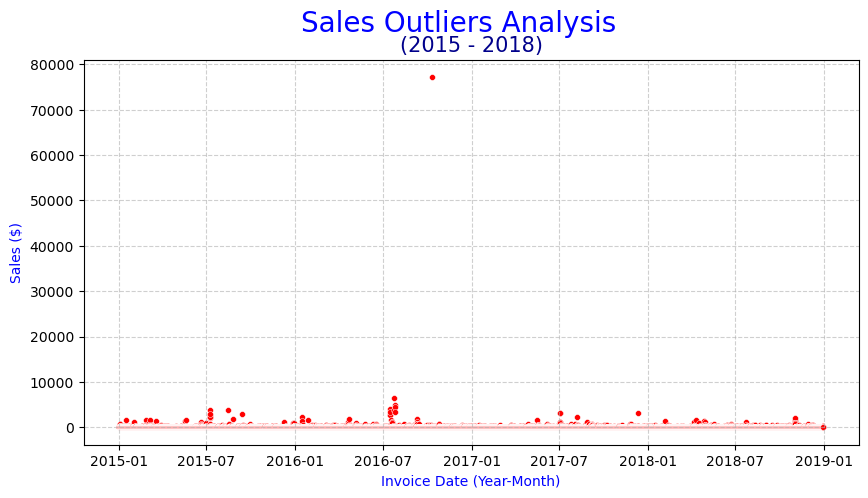

In [116]:
# Check for outliers in the Sales column by using scatter plot

# Create Scatter plot
plt.figure(figsize=(10,5)) # Set width & height
sns.scatterplot(x=df_filtered.InvoiceDate , y=df_filtered ['Sales'], color='red', s=18)

# Add grid for easier visual
plt.grid(True, linestyle='--', alpha=0.6)

# Scatter Tile & Axis Labels
plt.title('(2015 - 2018)', fontsize=15, color='darkblue')
plt.suptitle ('Sales Outliers Analysis', fontsize=20, color='blue')
plt.xlabel('Invoice Date (Year-Month)', color='blue')
plt.ylabel('Sales ($)', color='blue')
#plt.xticks(rotation=45)
plt.show()

**Sales Outlier Analysis**

_Plotting Sales($) against Invoice Date (Year-Month)_

**Outlier**: Single unidentifiable outlier isolated to **mid/late 2016** across the **2015 - 2018** dataset timeline.

**Impact**: This high-value transaction recorded approximately **$77K–$78K** in sales, far exceeding the usual baseline cluster where everyday transactions sit between **$1 and $10,000**.

In [117]:
# Refine Sales Outlier Results

# Find Outlier transaction and show record
df_filtered.loc[[df_filtered['Sales'].idxmax()]] 

,InvoiceNo,StockCode,Quantity,UnitPrice,InvoiceDate,Sales,Country,Description,Product_Category
36980,548691,23166,74215,1.04,2016-10-10,77183.6,United Kingdom,CHRISTMAS RETROSPOT STAR WOOD,CHRISTMAS


**Note**: Refine Sales Outlier Results

Result Output: Full record of the maximum sales transaction using **.loc** and **.idxmax** to identify single bulk Outlier (**CHRISTMAS RETROSPOT STAR WOOD**) from the Scatterplot check. 

## Task 5: Data Visualisation – Scatter Plot, Histogram, and Line Chart
### Objective: Create scatter plots, histograms, and line charts to better understand the data.

Instructions:

Use a scatter plot to examine the relationship between Quantity and Sales.

Use a histogram to visualise the distribution of the Sales column.

Use a line chart to show the trend of Sales over time.

Write 1–2 sentences explaining the insights from each visualisation.

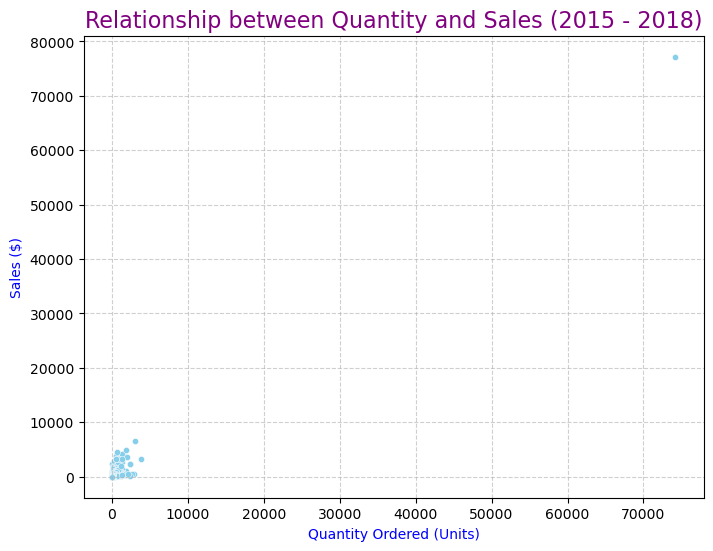

In [118]:
# Use a scatter plot to examine the relationsihip between Quantity and Sales

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Quantity', y='Sales', data=df_filtered, color='skyblue', s=20)


# Add grid for easier visual
plt.grid(True, linestyle='--', alpha=0.6)

# Scatter Title & Axis Labels
plt.title('Relationship between Quantity and Sales (2015 - 2018)', fontsize=16, color='purple')
plt.xlabel('Quantity Ordered (Units)', color='blue')
plt.ylabel('Sales ($)', color='blue')
plt.show()

Write 1–2 sentences explaining the insights from each visualization **Scatterplot**

**Relationship between Quantity & Sales**: 

_Plotting Sales ($) against Quantity Ordered (Units)_ 

Standard Operating Cluster & Bulk order Outlier 

There is a positive relationship where higher quantities ordered produce higher total sales. Most transactions are standard everyday purchases under **4,000** **units**, while a single bulk order of over **74,000** **units** creates an extreme outlier that drives total sales up to approximately **$77K**.


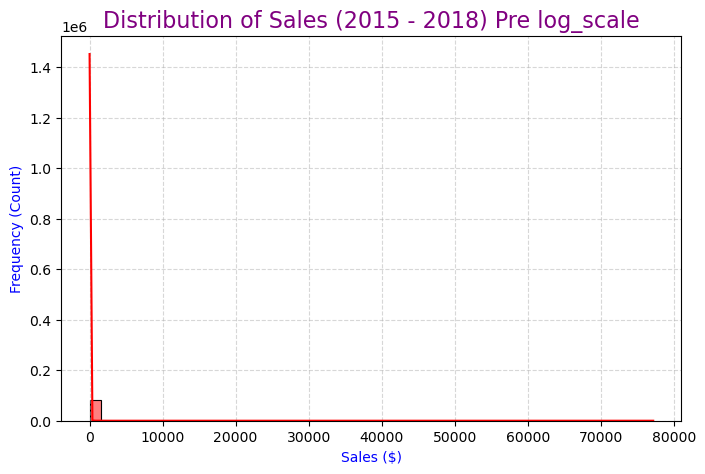

In [119]:
# Note: The following Histogram was generated before taking into account the impact of the Bulk Order Outlier Identified in the Outliers Check Scatterplot. 

# Use a histogram to visualise the distribution of the Sales column

plt.figure(figsize=(8, 5))
sns.histplot(df_filtered['Sales'], bins=50, kde=True, color='red')

plt.title('Distribution of Sales (2015 - 2018) Pre log_scale', fontsize=16, color='purple')
plt.xlabel('Sales ($)', color='blue')
plt.ylabel('Frequency (Count)', color='blue')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Note**: This histogram is heavily skewed because a single bulk outlier near **$77k** stretches the horizontal x-axis all the way to the end, compressing nearly all everyday transactions into the first bar. 

**IMPORTANT**: The next code block applies **log_scale=True** to make all data points, including the outlier, visually readable by expanding smaller sales in powers of **10 increments**.

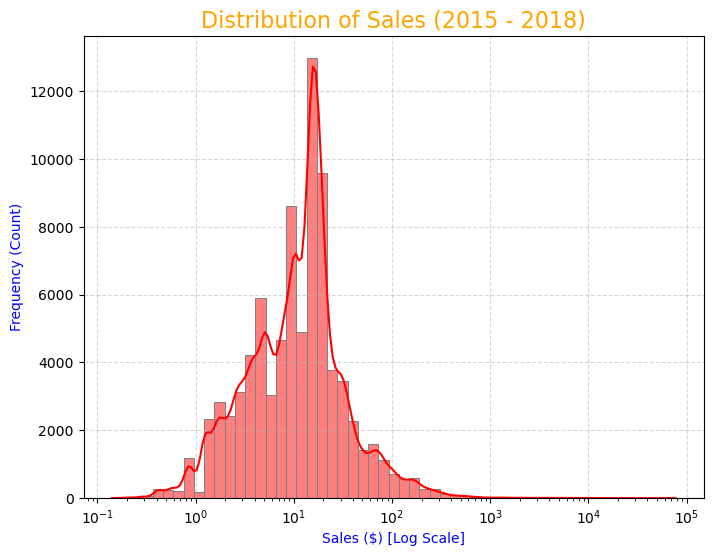

In [120]:
# Use a histogram to visualise the distribution of the Sales column

plt.figure(figsize=(8,6))

sns.histplot( data=df_filtered[df_filtered['Sales'] > 0], x='Sales', bins=55, color='red', kde=True, log_scale=True, edgecolor='grey')  

# Histogram Title & Axis Labels
plt.title('Distribution of Sales (2015 - 2018)', fontsize=16, color='Orange')
plt.xlabel('Sales ($) [Log Scale]', color='blue')
plt.ylabel('Frequency (Count)', color='blue')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Write 1–2 sentences explaining the insights from each visualization **Histogram**

**Distributions of Sales**

_Plotting Frequency (Count) against Sales ($)_

Applying **log_scale=True** expands the compressed data, revealing that most sales peak between **$10** and **$20**, with nearly **13,000** transactions recorded at the highest bar. Beyond **$1K**, transaction counts drop significantly, causing the red curve to flatline along the bottom x-axis all the way out to **$100K** which captures the single **$77k** bulk outlier (flatline: y-axis= **1 single** bulk transaction/frequency (count) against x-axis=**$77k** Sales.

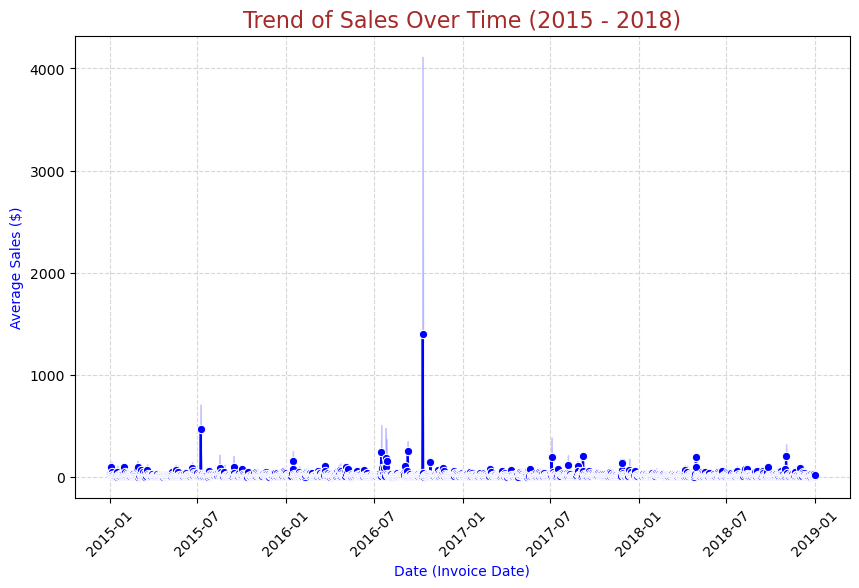

In [121]:
# Use a line chart to show the trend of Sales over time

plt.figure(figsize=(10, 6))

sns.lineplot(x='InvoiceDate', y= 'Sales', data=df_filtered, marker='o', color='blue')

# Linechart Tile & Axis Labels
plt.title('Trend of Sales Over Time (2015 - 2018)', fontsize=16, color='brown')
plt.xlabel('Date (Invoice Date)', color='blue')
plt.ylabel('Average Sales ($)', color='blue')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Write 1–2 sentences explaining the insights from each visualization **Linechart**

**Sales Over Time**

Plotting **Average Sales ($)** against **Invoice Date** shows that daily average sales remain low and stable from **2015 to 2018** with a minor spike in mid-2015 and later a major spike to **$1,400** in **late 2016** caused by a single **$77k** bulk order. The light blue error bar extending to **$4,000** on that date highlights extreme variance between that isolated bulk transaction and typical daily sales.

## Task 6: Correlation and Data Insights
### Objective: Identify the relationship between different numerical columns in the dataset.

Instructions:

Calculate the correlation between Quantity and Sales.

Visualise the correlation matrix using a heatmap.

Write 1–2 sentences explaining the insights from the visualisation.

In [122]:
# Calculate the correlation between Quantity and Sales

correlation = df_filtered[['Quantity','Sales']].corr()

print(correlation)

          Quantity     Sales
Quantity  1.000000  0.978609
Sales     0.978609  1.000000


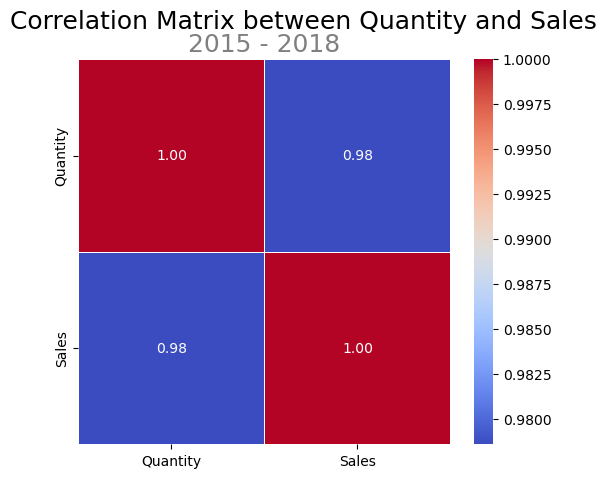

In [123]:
# Visualise the correlation matrix using a heatmap

plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidth=0.5)

# eatmap Tile & Axis Labels
plt.suptitle('Correlation Matrix between Quantity and Sales', fontsize=18)
plt.title('2015 - 2018', fontsize=18, color='grey')
plt.show()

_Write 1–2 sentences explaining the insights from the visualisation Correlation **Heatmap**_

Result: 

**Quantity vs. Quantity** / **Sales vs. Sales**: **1.00** (self-correlation)

**Quantity vs. Sales**: **0.98** (very strong positive correlation)

The heatmap shows a strong, high correlation score of **0.98** between Quantity and Sales, which suggests higher quantities drive higher sales but should be treated as a red flag for stakeholders to analyze further since an extreme outlier may be pulling the metric upward. In this case, the extreme outlier has been identified as the single bulk ordered (**CHRISTMAS RETROSPOT STAR WOOD**). Removing it shows what normal, day-to-day business transactions truly look like. To demonstrate this, the outlier has been temporarily removed in the next code block, resulting in a lower, more realistic baseline correlation of **0.66** for standard business transactions.

In [124]:
# 1. Create a temporary dataframe without the maximum sales (Outlier) record
df_remove_outlier = df_filtered.drop(index=df_filtered['Sales'].idxmax())

# 2. Recalculate the correlation matrix (Outlier Removed)
corr_remove_outlier = df_remove_outlier[['Quantity', 'Sales']].corr()
print(corr_remove_outlier)

          Quantity     Sales
Quantity  1.000000  0.661119
Sales     0.661119  1.000000


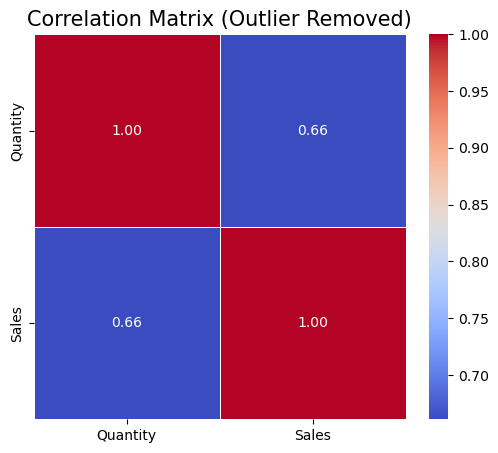

In [125]:
# Visualise the correlation matrix using a heatmap (Outlier Removed)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_remove_outlier, annot=True, cmap='coolwarm', fmt='.2f', linewidth=0.5)
plt.title('Correlation Matrix (Outlier Removed)', fontsize=15)
plt.show()

**Note**: Outlier data temporarily removed to demonstrate the impact on correlation compared to standard day-to-day business transactions, reducing the correlation from 0.98 to 0.66.

## Task 7: Grouping and Aggregating
### Objective: Perform grouping and aggregation operations to summarise the data.

Instructions:

GroupBy operation: Group by Product_Category and calculate the total Sales per category.

Create a Pivot Table to show Sales by Country and Product_Category.

In [126]:
# GroupBy operation: Group by Product_Category and calculate the total Sales per category

total_sales_per_category = df_filtered.groupby('Product_Category')['Sales'].sum().reset_index() 
total_sales_per_category = total_sales_per_category.sort_values(by='Sales', ascending=False)


# rename column 'Sales' to 'Total_Sales)' for cleaner result output purposes  
display(total_sales_per_category.rename(columns={'Sales' : 'Total_Sales'}))

In [127]:
# Create a Pivot Table to show Sales by Country and Product_Category

pivot_table = df_filtered.pivot_table(values='Sales', index='Country', columns='Product_Category', aggfunc='sum',fill_value=0).reset_index()

display(pivot_table)

The pivot table shows combined total sales across each product category by country, filling missing values of no transactions with zero (0) for easy comparison.

## Submission Guidelines:
Submit the Python notebook with all the tasks and visualisations.

Ensure that each task is clearly explained and that all steps are followed.

Include markdown explanations where necessary to explain your thought process.

Good work. I assume that all the coding and explanations have been completed without any help from AI. Please note that relying on AI during the learning stage may hinder candidate's learning and make it more difficult to progress further.
